In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.optimize import minimize
from scipy.special import expit

from dd_kable_analysis.config_loader import load_config
from dd_kable_analysis.data_io import (
    get_confounds_data,
    get_subids_bids_dir,
    load_tsv_data,
    resolve_file,
)

In [2]:
import sys
from pathlib import Path

notebook_dir = Path.cwd()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from subjective_value_helpers import (
    compute_trialwise_measures,
    fit_subject_collect_all_attempts,
    split_half_reliability,
)

# What is this?
For each subject this code estimates trial-specific subjective value.  To check the algorithm, we start with a split half analysis.  This was done since earlier code indicated subjects were getting caught in local minima and we were unsure how much this might be impacting the SV estimates.  

## Subjective Value (SV) Estimation

This notebook estimates each participant's delay discounting behavior using a hyperbolic discounting model. For each delayed reward, subjective value (SV) is computed as:

SV = Amount / (1 + k × Delay)

where `k` is the discount rate. Larger values of `k` indicate steeper discounting (greater preference for immediate rewards), while smaller values indicate greater willingness to wait for delayed rewards.

Choices are modeled using a logistic choice function. The difference in value between the delayed reward and the fixed immediate reward ($20) is calculated as:

DV = SV_delayed − 20

The probability of choosing the delayed reward is then:

P(choose delayed) = logistic(β × DV)

where `β` is an inverse-temperature parameter that controls choice consistency. Larger values of `β` produce more deterministic choices, whereas smaller values allow more variability in responding.

Model parameters (`k` and `β`) are estimated by maximum likelihood. Optimization is performed in log-parameter space (`log(k)` and `log(β)`) to ensure that both parameters remain positive. Because nonlinear optimization can occasionally converge to local minima, a multistart approach is used. The model is fit repeatedly from randomly selected starting values, and the solution with the lowest negative log-likelihood is retained as the final estimate. Diagnostics are also recorded, including the number of successful convergences, failed optimizations, warnings, and the variability of parameter estimates across successful starts.

## Split-Half Reliability Analysis

To assess the stability of the fitted parameters, a split-half reliability analysis is performed. Trials are randomly divided into two non-overlapping halves, and the discounting model is fit independently to each subset of trials using the same multistart estimation procedure described above.

The resulting parameter estimates (`k` and `β`) from the two halves are compared in several ways:

* `k_diff`: absolute difference between the two discount-rate estimates.
* `beta_diff`: absolute difference between the two inverse-temperature estimates.
* `sv_correlation`: correlation between subjective values predicted by the two fitted `k` values across all trials.
* `sv_mae`: mean absolute difference between the two sets of predicted subjective values.

High SV correlations and small parameter differences suggest that the participant's discounting behavior is internally consistent and that the fitted model is stable across subsets of trials. Large discrepancies may indicate noisy responding, insufficient data, or poor model identifiability.

In [3]:
cfg = load_config()

good_subs_csv = cfg.subject_lists / 'initial_qa_pass_subjects_runs.csv'
good_subs = pd.read_csv(good_subs_csv)


In [4]:
all_behav = []

for row in good_subs.itertuples(index=False):
    sub_id = row.sub_id
    session = row.session
    run = row.run
    behav_file = resolve_file(cfg, sub_id, session, run, 'behav')
    behav_data = load_tsv_data(behav_file)
    behav_data['sub_id'] = sub_id
    behav_data['session'] = session
    behav_data['run'] = run
    all_behav.append(behav_data)

all_behav_df = pd.concat(all_behav)
all_behav_df

,onset,duration,amount,Delay,choseAccept,RT,choseRight,sub_id,session,run
0,15.822,4,66,58,1.0,1.993,1.0,dmp0011,scan1,1
1,24.855,4,39,95,0.0,1.024,0.0,dmp0011,scan1,1
2,32.888,4,69,172,0.0,1.071,0.0,dmp0011,scan1,1
3,42.937,4,23,42,0.0,1.101,0.0,dmp0011,scan1,1
4,56.987,4,77,142,1.0,1.739,1.0,dmp0011,scan1,1
...,...,...,...,...,...,...,...,...,...,...
25,264.904,4,64,89,1.0,1.031,1.0,dmp1291,scan1,4
26,272.937,4,41,174,0.0,2.377,0.0,dmp1291,scan1,4
27,282.970,4,76,161,1.0,1.414,1.0,dmp1291,scan1,4
28,299.003,4,33,103,0.0,1.914,0.0,dmp1291,scan1,4


## Split half analysis
All looks good!

In [5]:
# ---------------------------------------------------------
# Split-half reliability across all subjects
# ---------------------------------------------------------
split_half_results = []

for sub_id, df_sub in all_behav_df.groupby('sub_id'):
    result = split_half_reliability(df_sub, n_starts=20)
    result['sub_id'] = sub_id
    split_half_results.append(result)

sh_df = pd.DataFrame(split_half_results).dropna(
    subset=['k_half1', 'k_half2', 'beta_half1', 'beta_half2', 'sv_correlation']
)


In [6]:
failed_subjects = [
    result
    for result in split_half_results
    if (
        result['half1_n_failed_initializations']
        + result['half2_n_failed_initializations']
    )
    > 0
]

total_failed_initializations = sum(
    result['half1_n_failed_initializations'] + result['half2_n_failed_initializations']
    for result in split_half_results
)
total_initializations = 2 * 20 * len(split_half_results)
failure_pct = (
    (100 * total_failed_initializations / total_initializations)
    if total_initializations
    else np.nan
)

warning_subjects = [
    result
    for result in split_half_results
    if (result['half1_n_warnings'] + result['half2_n_warnings']) > 0
]
total_warnings = sum(
    result['half1_n_warnings'] + result['half2_n_warnings']
    for result in split_half_results
)
warning_pct = (
    (100 * total_warnings / total_initializations) if total_initializations else np.nan
)

print(f'{len(failed_subjects)} subjects had at least one failed initialization.')
print(f'{failure_pct:.2f}% of all initializations failed across split-half fits.')
print(f'{len(warning_subjects)} subjects had at least one optimization warning.')
print(
    f'{warning_pct:.2f}% of all initializations emitted warnings across split-half fits.'
)

1 subjects had at least one failed initialization.
0.02% of all initializations failed across split-half fits.
29 subjects had at least one optimization warning.
1.59% of all initializations emitted warnings across split-half fits.


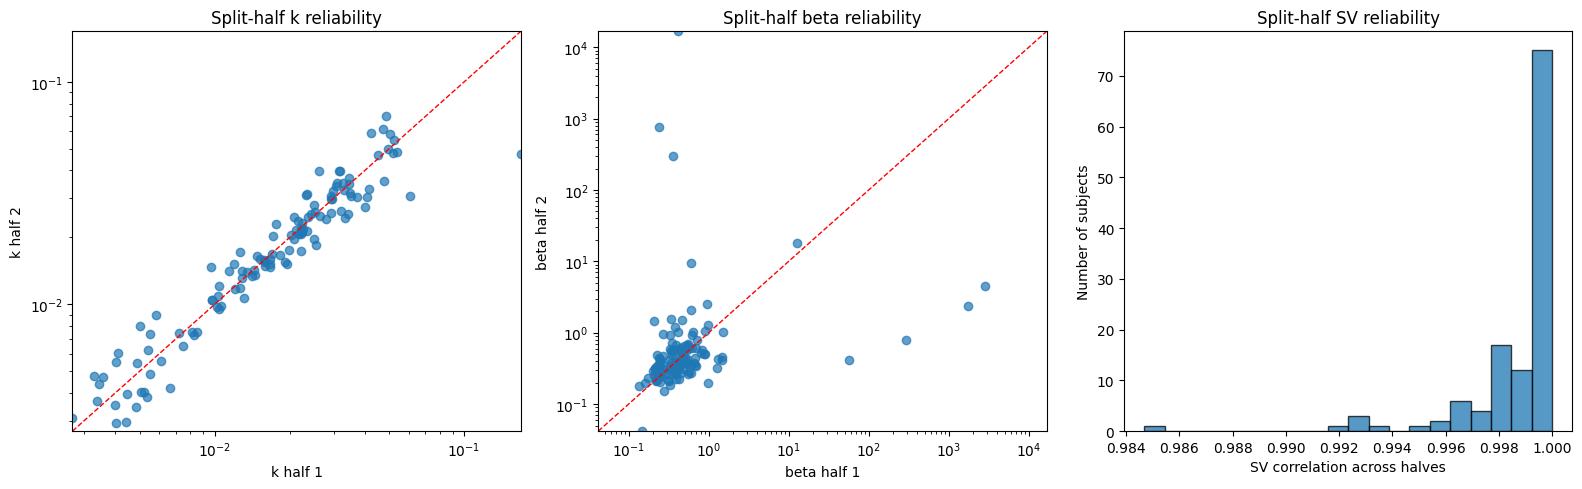

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

k_values = sh_df[['k_half1', 'k_half2']].to_numpy().ravel()
beta_values = sh_df[['beta_half1', 'beta_half2']].to_numpy().ravel()

k_values = k_values[np.isfinite(k_values) & (k_values > 0)]
beta_values = beta_values[np.isfinite(beta_values) & (beta_values > 0)]

k_min = max(np.nanmin(k_values), 1e-6)
k_max = np.nanmax(k_values)
beta_min = max(np.nanmin(beta_values), 1e-6)
beta_max = np.nanmax(beta_values)

axes[0].scatter(sh_df['k_half1'], sh_df['k_half2'], alpha=0.7)
axes[0].plot([k_min, k_max], [k_min, k_max], 'r--', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(k_min, k_max)
axes[0].set_ylim(k_min, k_max)
axes[0].set_xlabel('k half 1')
axes[0].set_ylabel('k half 2')
axes[0].set_title('Split-half k reliability')

axes[1].scatter(sh_df['beta_half1'], sh_df['beta_half2'], alpha=0.7)
axes[1].plot([beta_min, beta_max], [beta_min, beta_max], 'r--', linewidth=1)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlim(beta_min, beta_max)
axes[1].set_ylim(beta_min, beta_max)
axes[1].set_xlabel('beta half 1')
axes[1].set_ylabel('beta half 2')
axes[1].set_title('Split-half beta reliability')

axes[2].hist(sh_df['sv_correlation'], bins=20, edgecolor='black', alpha=0.75)
axes[2].set_xlabel('SV correlation across halves')
axes[2].set_ylabel('Number of subjects')
axes[2].set_title('Split-half SV reliability')

plt.tight_layout()
plt.show()

# Fitting the models on the full data

In [8]:
# ---------------------------------------------------------
# Multistart subject fits
# ---------------------------------------------------------
all_subject_data = {}

for sub_id, df_sub in all_behav_df.groupby('sub_id'):
    all_subject_data[sub_id] = fit_subject_collect_all_attempts(df_sub, n_starts=20)


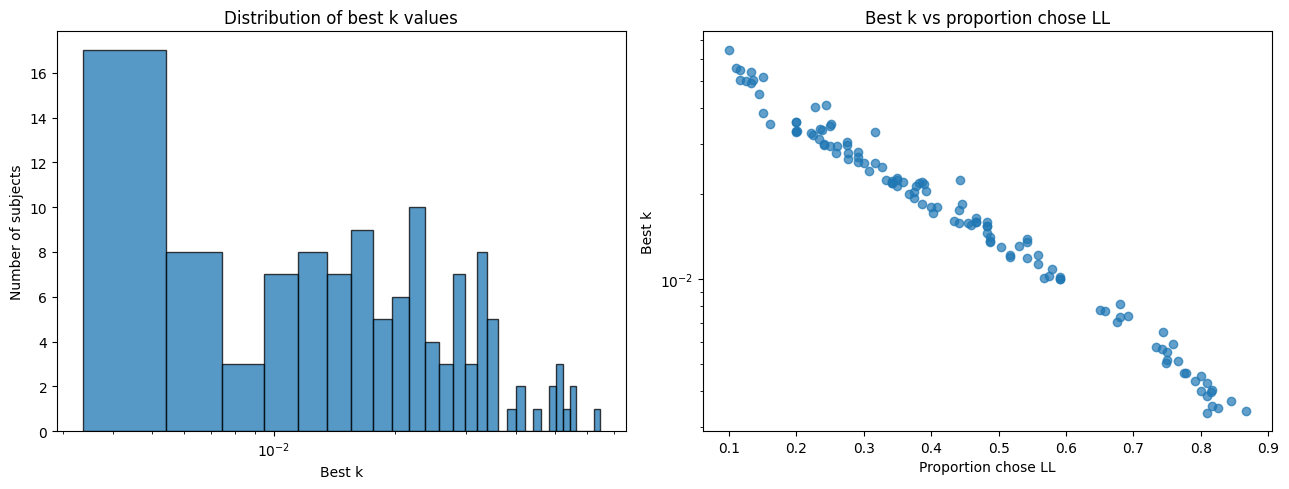

0 subjects had at least one failed initialization.
0.00% of all initializations failed across the 20-start fits.


In [10]:
plot_data = []

for sub_id, results in all_subject_data.items():
    plot_data.append(
        {
            'sub_id': sub_id,
            'best_k': results['best_k'],
            'prop_chose_LL': results['prop_chose_LL'],
        }
    )

plot_df = pd.DataFrame(plot_data).dropna(subset=['best_k', 'prop_chose_LL'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(plot_df['best_k'], bins=30, edgecolor='black', alpha=0.75)
axes[0].set_xscale('log')
axes[0].set_xlabel('Best k')
axes[0].set_ylabel('Number of subjects')
axes[0].set_title('Distribution of best k values')

axes[1].scatter(plot_df['prop_chose_LL'], plot_df['best_k'], alpha=0.7)
axes[1].set_xlabel('Proportion chose LL')
axes[1].set_ylabel('Best k')
axes[1].set_yscale('log')
axes[1].set_title('Best k vs proportion chose LL')

plt.tight_layout()
plt.show()

failed_subjects = [
    result
    for result in all_subject_data.values()
    if result['n_failed_initializations'] > 0
]
total_failed_initializations = sum(
    result['n_failed_initializations'] for result in all_subject_data.values()
)
total_initializations = 20 * len(all_subject_data)
failure_pct = (
    100 * total_failed_initializations / total_initializations
    if total_initializations
    else np.nan
)

print(f'{len(failed_subjects)} subjects had at least one failed initialization.')
print(f'{failure_pct:.2f}% of all initializations failed across the 20-start fits.')

In [11]:
cfg.output_root

PosixPath('/oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results')

In [12]:
# ---------------------------------------------------------
# Save final trial-level SV outputs (full-data fit only)
# ---------------------------------------------------------
output_root = Path(cfg.output_root) / 'subjective_value_estimates'
output_root.mkdir(parents=True, exist_ok=True)

trialwise_results = []
skipped_subjects = []

for sub_id, df_sub in all_behav_df.groupby('sub_id'):
    if sub_id not in all_subject_data:
        skipped_subjects.append(sub_id)
        continue

    best_k = all_subject_data[sub_id]['best_k']
    if not np.isfinite(best_k):
        skipped_subjects.append(sub_id)
        continue

    trialwise_results.append(compute_trialwise_measures(df_sub, best_k))

if len(trialwise_results) == 0:
    raise RuntimeError('No valid subject fits were available for SV export.')

df_trialwise = pd.concat(trialwise_results, ignore_index=False).copy()
df_trialwise['source_row_index'] = df_trialwise.index

group_cols = ['sub_id', 'session', 'run']
output_records = []

for (sub_id, session, run), g in df_trialwise.groupby(group_cols, dropna=False):
    sub_label = str(sub_id).replace('sub-', '')
    ses_label = str(session).replace('ses-', '') if pd.notna(session) else None

    run_str = str(run)
    try:
        run_part = f'run-{int(float(run_str)):02d}'
    except ValueError:
        run_part = f'run-{run_str}'

    out_dir = output_root / f'sub-{sub_label}'
    if ses_label is not None:
        out_dir = out_dir / f'ses-{ses_label}'
    out_dir = out_dir / 'func'
    out_dir.mkdir(parents=True, exist_ok=True)

    fname = f'sub-{sub_label}'
    if ses_label is not None:
        fname += f'_ses-{ses_label}'
    fname += f'_task-dd_{run_part}_desc-subjectivevalue_events.tsv'

    out_df = g.copy().sort_values('onset').reset_index(drop=True)
    out_df['trial_index_within_file'] = np.arange(len(out_df))

    keep_cols = [
        'onset',
        'sub_id',
        'session',
        'run',
        'trial_index_within_file',
        'source_row_index',
        'SV_LL',
        'SV_chosen',
        'SV_unchosen',
    ]
    out_df = out_df[keep_cols]

    out_path = out_dir / fname
    out_df.to_csv(out_path, sep='\t', index=False)

    output_records.append(
        {
            'sub_id': sub_id,
            'session': session,
            'run': run,
            'n_trials_saved': len(out_df),
            'output_file': str(out_path),
        }
    )

export_manifest = pd.DataFrame(output_records)
manifest_path = output_root / 'subjective_value_export_manifest.tsv'
export_manifest.to_csv(manifest_path, sep='\t', index=False)

print(f'Saved {len(export_manifest)} subject/run files to {output_root}')
print(f'Manifest written to {manifest_path}')
if len(skipped_subjects) > 0:
    print(f'Skipped {len(skipped_subjects)} subjects due to missing/non-finite fits.')

Saved 454 subject/run files to /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/subjective_value_estimates
Manifest written to /oak/stanford/groups/russpold/users/buckholtz/DD_Kable/derivatives/analysis_results/subjective_value_estimates/subjective_value_export_manifest.tsv
